# RecGen — single-view inference example

Runs `recgen_inference` on one of the bundled example scenes and visualises the result:
1. Input RGB / depth / mask preview
2. Inference + save
3. **Scene overlay** — the reconstructed mesh projected back into the original RGB using the predicted 6-DoF pose
4. **Turntable video** — Gaussian colour + mesh normals, rendered with the internal TRELLIS CUDA renderers
5. Multi-view inference

```bash
pip install -e .
pip install jupyter matplotlib imageio imageio-ffmpeg
```

In [13]:
import os
os.environ['SPCONV_ALGO'] = 'native'
os.environ.setdefault('PYOPENGL_PLATFORM', 'egl')

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Video, display

from recgen_inference import build_recgen, generate

## 1. Build the pipeline

The first call downloads checkpoints from HuggingFace (`TRI-ML/RecGen`).

In [14]:
print('available checkpoints:', build_recgen.list_checkpoints())
pipeline = build_recgen.build('recgen_base.multiview_stereo')

available checkpoints: ['recgen_base.multiview_stereo']
[recgen_inference] Loading pipeline...


Using cache found in /home/andrii_newtheory_ai/.cache/torch/hub/facebookresearch_dinov2_main


[recgen_inference] Pipeline loaded.


## 2. Load an example RGB-D view

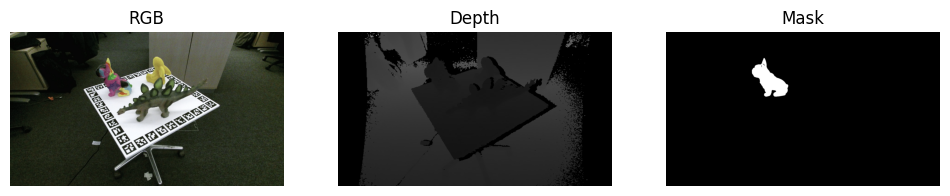

In [28]:
EXAMPLES = os.path.join(os.path.dirname(os.getcwd()), 'examples')
idx = 0 #0-5 provided in the repo or use your own

rgb = cv2.cvtColor(cv2.imread(f'{EXAMPLES}/ex{idx}_rgb.png'), cv2.COLOR_BGR2RGB)
depth = cv2.imread(f'{EXAMPLES}/ex{idx}_depth.png', cv2.IMREAD_UNCHANGED)
mask = cv2.imread(f'{EXAMPLES}/ex{idx}_mask.png', cv2.IMREAD_UNCHANGED)
if mask.ndim == 3:
    mask = mask[:, :, 0]

intrinsics = np.array([
    [1062.203,   0.0,   971.3832],
    [  0.0,   1060.9691, 540.0661],
    [  0.0,     0.0,       1.0  ],
])

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(rgb);                ax[0].set_title('RGB');   ax[0].axis('off')
ax[1].imshow(depth, cmap='gray'); ax[1].set_title('Depth'); ax[1].axis('off')
ax[2].imshow(mask, cmap='gray');  ax[2].set_title('Mask');  ax[2].axis('off')
plt.show()

## 3. Run inference and save

In [29]:
REPO_ROOT = os.path.dirname(os.getcwd())
OUT_DIR = os.path.join(REPO_ROOT, 'outputs', 'notebook_outputs_single_view')
OUT_DIR_MV = os.path.join(REPO_ROOT, 'outputs', 'notebook_outputs_multi_view')
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(OUT_DIR_MV, exist_ok=True)

result = generate(pipeline, image=rgb, depth=depth, mask=mask, intrinsics=intrinsics, seed=42)

print('mesh   :', result.mesh.vertices.shape[0], 'vertices,', result.mesh.faces.shape[0], 'faces')
print('pose   :', result.pose_matrix)
print('quat   :', result.pose_quat)

result.save(OUT_DIR, save_splat=True, save_glb=False)

[DEBUG encode_pointmap] Model sparse_structure_pose_flow_model
[DEBUG encode_mask] Mask tensor shape: torch.Size([1, 1, 518, 518]), min: 0.0, max: 1.0
[DEBUG encode_mask] Model sparse_structure_pose_flow_model


Sampling: 100%|██████████| 25/25 [00:02<00:00,  9.42it/s]


[DEBUG encode_pointmap] Model slat_flow_model
[DEBUG encode_mask] Mask tensor shape: torch.Size([1, 1, 518, 518]), min: 0.0, max: 1.0
[DEBUG encode_mask] Model slat_flow_model
  SLAT pose conditioning: added 2 token(s)


Sampling: 100%|██████████| 25/25 [00:04<00:00,  5.22it/s]


  Applied denormalization (std/mean)
  slat.feats.shape: torch.Size([13013, 8])
[DEBUG sample_slat] Done

mesh   : 292014 vertices, 584024 faces
pose   : [[-0.44916418  1.14957345 -0.25319874  0.55227518]
 [ 0.68985879  0.03748377 -1.05359709  0.35760015]
 [-0.95379436 -0.51424992 -0.64280671  0.60714298]
 [ 0.          0.          0.          1.        ]]
quat   : [ 0.55227518  0.35760015  0.60714298  0.53008119  0.68855928 -0.45181675
  0.20189521]


## 4. Scene overlay — does the posed generated shape overlap with the object?

Projects the raw (object-frame) mesh into the original RGB image using `result.pose_matrix` and
`result.cam2ncam`. If the pose is correct, the rendered mesh lands exactly on top of the object
in the scene.

saved /home/andrii_newtheory_ai/projects/recgen/outputs/notebook_outputs_single_view/scene_overlay.png


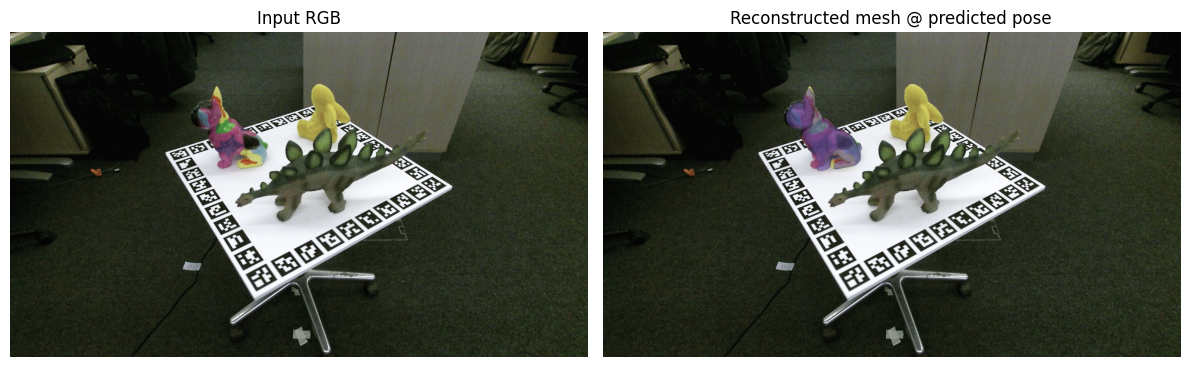

In [30]:
def render_scene_overlay(camera_frame_mesh, intrinsics, original_rgb,
                         mesh_color=(116, 92, 180), opacity=0.6):
    """Project a mesh that is already in the camera frame into the RGB image."""
    verts_cam = np.asarray(camera_frame_mesh.vertices, dtype=np.float64)
    faces = np.asarray(camera_frame_mesh.faces)

    H, W = original_rgb.shape[:2]
    K = np.asarray(intrinsics, dtype=np.float64)
    z = verts_cam[:, 2]
    valid = z > 1e-3
    z_safe = np.where(valid, z, 1.0)
    u = K[0, 0] * verts_cam[:, 0] / z_safe + K[0, 2]
    v = K[1, 1] * verts_cam[:, 1] / z_safe + K[1, 2]
    pixels = np.stack([u, v], axis=1)

    v0, v1, v2 = verts_cam[faces[:, 0]], verts_cam[faces[:, 1]], verts_cam[faces[:, 2]]
    normals = np.cross(v1 - v0, v2 - v0)
    nlen = np.linalg.norm(normals, axis=1, keepdims=True)
    normals /= np.where(nlen > 0, nlen, 1.0)
    diffuse = np.clip(0.25 + 0.75 * np.abs(normals[:, 2]), 0, 1)

    face_z = z[faces].mean(axis=1)
    face_valid = valid[faces].all(axis=1)
    order = np.argsort(-face_z)

    mc = np.array(mesh_color, dtype=np.float32)
    rendered = np.zeros((H, W, 3), dtype=np.uint8)
    mask_img = np.zeros((H, W), dtype=np.uint8)
    for fi in order:
        if not face_valid[fi]:
            continue
        pts = pixels[faces[fi]].astype(np.int32)
        if pts[:, 0].max() < 0 or pts[:, 0].min() >= W: continue
        if pts[:, 1].max() < 0 or pts[:, 1].min() >= H: continue
        color = (mc * diffuse[fi]).astype(np.uint8).tolist()
        cv2.fillPoly(rendered, [pts.reshape(-1, 1, 2)], color)
        cv2.fillPoly(mask_img, [pts.reshape(-1, 1, 2)], 255)

    bg = original_rgb.astype(np.float32) / 255.0
    mf = (mask_img > 0).astype(np.float32)[:, :, None]
    mesh_f = rendered.astype(np.float32) / 255.0
    comp = bg * (1 - opacity * mf) + mesh_f * opacity * mf
    return np.clip(comp * 255, 0, 255).astype(np.uint8)

overlay = render_scene_overlay(result.mesh, intrinsics, rgb)

overlay_path = os.path.join(OUT_DIR, 'scene_overlay.png')
cv2.imwrite(overlay_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
print(f'saved {overlay_path}')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(rgb);     ax[0].set_title('Input RGB'); ax[0].axis('off')
ax[1].imshow(overlay); ax[1].set_title('Reconstructed mesh @ predicted pose'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## 5. Turntable video — Gaussian colour + mesh normals

Uses the internal TRELLIS CUDA renderers (`render_video`) on the raw `MeshExtractResult` and
`Gaussian` representations — the same code paths the training pipeline uses. Produces a
side-by-side MP4: textured Gaussian splat on the left, shaded mesh normals on the right.

This is the same approach used by the original RecGen Gradio demo.

In [31]:
import imageio.v2 as imageio
from recgen_inference.recgen_modules.utils import render_utils

outputs = result._outputs
video_color  = render_utils.render_video(outputs['gaussian'][0], num_frames=120)['color']
video_normal = render_utils.render_video(outputs['mesh'][0],     num_frames=120)['normal']
video = [np.concatenate([video_color[i], video_normal[i]], axis=1) for i in range(len(video_color))]

video_path = os.path.join(OUT_DIR, 'turntable.mp4')
imageio.mimsave(video_path, video, fps=30)
print(f'saved {video_path} ({len(video)} frames)')
display(Video(video_path, embed=True, width=720))

Rendering: 120it [00:00, 157.81it/s]
Rendering: 120it [00:00, 178.00it/s]


saved /home/andrii_newtheory_ai/projects/recgen/outputs/notebook_outputs_single_view/turntable.mp4 (120 frames)


## 6. Multi-view inference

Pass an anchor view plus one or more extra views. The result is expressed in the anchor's camera frame.


[run_pointmap_multiview] Processing 2 views, SLAT mode: multi-view (2)
[DEBUG get_cond_multiview] Processing 2 views
[DEBUG encode_pointmap] Model sparse_structure_pose_flow_model
[DEBUG encode_pointmap] Model sparse_structure_pose_flow_model
[DEBUG encode_mask] Mask tensor shape: torch.Size([1, 1, 518, 518]), min: 0.0, max: 1.0
[DEBUG encode_mask] Model sparse_structure_pose_flow_model
[DEBUG encode_mask] Mask tensor shape: torch.Size([1, 1, 518, 518]), min: 0.0, max: 1.0
[DEBUG encode_mask] Model sparse_structure_pose_flow_model


Sampling: 100%|██████████| 25/25 [00:02<00:00, 10.93it/s]


[DEBUG get_cond_multiview] Processing 2 views
[DEBUG encode_pointmap] Model slat_flow_model
[DEBUG encode_pointmap] Model slat_flow_model
[DEBUG encode_mask] Mask tensor shape: torch.Size([1, 1, 518, 518]), min: 0.0, max: 1.0
[DEBUG encode_mask] Model slat_flow_model
[DEBUG encode_mask] Mask tensor shape: torch.Size([1, 1, 518, 518]), min: 0.0, max: 1.0
[DEBUG encode_mask] Model slat_flow_model
  SLAT pose conditioning: added 2 token(s)


Sampling: 100%|██████████| 25/25 [00:04<00:00,  5.04it/s]


  Applied denormalization (std/mean)
  slat.feats.shape: torch.Size([7872, 8])
[DEBUG sample_slat] Done

saved /home/andrii_newtheory_ai/projects/recgen/outputs/notebook_outputs_multi_view/scene_overlay.png


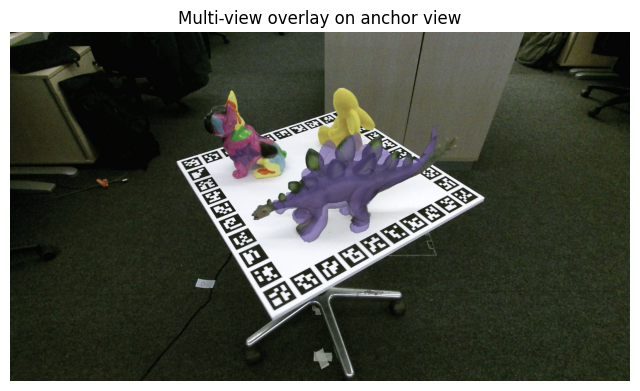

Rendering: 120it [00:00, 165.98it/s]
Rendering: 120it [00:00, 212.63it/s]


In [32]:
from recgen_inference import generate_multiview
idx = 1
def load_view(i):
    rgb = cv2.cvtColor(cv2.imread(f'{EXAMPLES}/ex{i}_rgb.png'), cv2.COLOR_BGR2RGB)
    depth = cv2.imread(f'{EXAMPLES}/ex{i}_depth.png', cv2.IMREAD_UNCHANGED)
    mask  = cv2.imread(f'{EXAMPLES}/ex{i}_mask.png',  cv2.IMREAD_UNCHANGED)
    if mask.ndim == 3: mask = mask[:, :, 0]
    return {'rgb': rgb, 'depth': depth, 'mask': mask, 'camera_intrinsics': intrinsics}

if getattr(pipeline, 'is_multiview', False):
    result_mv = generate_multiview(pipeline, anchor_view=load_view(idx), second_views=[load_view(idx+1)])
    result_mv.save(OUT_DIR_MV)

    overlay_mv = render_scene_overlay(result_mv.mesh, intrinsics, load_view(idx)['rgb'])
    overlay_mv_path = os.path.join(OUT_DIR_MV, 'scene_overlay.png')
    cv2.imwrite(overlay_mv_path, cv2.cvtColor(overlay_mv, cv2.COLOR_RGB2BGR))
    print(f'saved {overlay_mv_path}')

    plt.figure(figsize=(8, 5))
    plt.imshow(overlay_mv); plt.title('Multi-view overlay on anchor view'); plt.axis('off'); plt.show()

    outs_mv = result_mv._outputs
    video_color_mv  = render_utils.render_video(outs_mv['gaussian'][0], num_frames=120)['color']
    video_normal_mv = render_utils.render_video(outs_mv['mesh'][0],     num_frames=120)['normal']
    video_mv = [np.concatenate([video_color_mv[i], video_normal_mv[i]], axis=1) for i in range(len(video_color_mv))]
    video_mv_path = os.path.join(OUT_DIR_MV, 'turntable.mp4')
    imageio.mimsave(video_mv_path, video_mv, fps=30)
    display(Video(video_mv_path, embed=True, width=720))